In [ ]:
!pip install torch torchvision
!pip install opencv-python
!pip install tqdm scikit-image Pillow pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 39.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -*- coding: utf-8 -*-

import argparse
import os
import numpy as np
import math
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch
from os.path import splitext
from os import listdir
import numpy as np
from glob import glob
import logging
from PIL import Image
from torchvision import transforms, utils
import random
from scipy.ndimage import rotate
from PIL import Image, ImageEnhance
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import torchvision
from skimage.morphology import skeletonize,remove_small_objects
from skimage import io
import shutil

class Segmenter(nn.Module):
    def __init__(self, input_channels, n_filters, n_classes, bilinear=False):
        super(Segmenter, self).__init__()

        self.n_channels = input_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(input_channels, n_filters)
        self.down1 = Down(n_filters, 2*n_filters)
        self.down2 = Down(2*n_filters, 4*n_filters)
        self.down3 = Down(4*n_filters, 8*n_filters)
        self.down4 = Down(8*n_filters, 16*n_filters)

        self.up1 = Up_new(16*n_filters, 8*n_filters, bilinear)
        self.up2 = Up_new(8*n_filters, 4*n_filters, bilinear)
        self.up3 = Up_new(4*n_filters, 2*n_filters, bilinear)
        self.up4 = Up_new(2*n_filters, 1*n_filters, bilinear)
        self.outc = OutConv(n_filters, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

class Discriminator(nn.Module):
    def __init__(self, input_channels, n_filters, n_classes, bilinear=True):
        super(Discriminator, self).__init__()

        self.n_channels = input_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(input_channels, n_filters)
        self.down1 = Down(n_filters, 2*n_filters)
        self.down2 = Down(2*n_filters, 4*n_filters)
        self.down3 = Down(4*n_filters, 8*n_filters)
        self.down4 = Down(8*n_filters, 16*n_filters)

        self.up1 = Up(16*n_filters, 8*n_filters, bilinear)
        self.up2 = Up(8*n_filters, 4*n_filters, bilinear)
        self.up3 = Up(4*n_filters, 2*n_filters, bilinear)
        self.up4 = Up(2*n_filters, 1*n_filters, bilinear)
        self.outc = OutConv(n_filters, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits


class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        mid_channels = out_channels
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=False):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)

        #else:
        #    self.up = nn.ConvTranspose2d(in_channels , in_channels // 2, kernel_size=2, stride=2)
        #    self.conv = DoubleConv(in_channels, out_channels)

        else:
            self.conv_bottom = bottom_conv(in_channels, out_channels)
            self.up = nn.Upsample(scale_factor=2)
            self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x1, x2):
        x1 = self.conv_bottom(x1)
        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class bottom_conv(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        mid_channels = out_channels
        if not mid_channels:
            mid_channels = out_channels
        self.single_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.single_conv(x)




class DoubleAdd(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.activation = nn.Sequential(
            nn.BatchNorm2d(out_channels//2),
            nn.ReLU(inplace=True),
        )

    def forward(self, x1, x2):

        n, c, h, w = list(x1.size())
        x1 = torch.reshape(input=x1, shape=(n, c // 2, 2, h, w))
        x1 = x1.sum(dim=2)
        x1 = self.activation(x1)

        n, c, h, w = list(x2.size())
        x2 = torch.reshape(input=x2, shape=(n, c // 2, 2, h, w))
        x2 = x2.sum(dim=2)
        x2 = self.activation(x2)
        return torch.cat([x1, x2], dim=1)


class Up_new(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, bilinear=False):
        super().__init__()
        self.conv_bottom = bottom_conv(in_channels,out_channels)
        self.up = nn.Upsample(scale_factor=2)
        self.add = DoubleAdd(in_channels, out_channels)
        self.conv = DoubleConv(in_channels, out_channels)


    def forward(self, x1, x2):
        x = self.conv_bottom(x1)
        x = self.up(x)
        #road 1

        x_1 = self.add(x,x2)

        #road 2
        x_2 = torch.cat([x, x2], dim=1)
        x_2 = self.conv(x_2)

        return torch.add(x_1, x_2)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class SEDataset_out():
    def __init__(self, img_path, img_size , dataset_name, pthrehold, train_or=True):
        self.img_path = img_path
        self.img_size = img_size
        self.dataset_name = dataset_name
        self.pthrehold = pthrehold
        self.train_or = train_or

        self.img = Image.open(img_path)
        self.ori_width, self.ori_height = self.img.size
        self.img = self.img.resize(self.img_size)
        self.img = self.preprocess(self.img, self.dataset_name, self.img_size, self.train_or, self.pthrehold)

    def __len__(self):
        return 1

    @classmethod
    def pad_img(cls, img, img_size):
        img_h, img_w = img.shape[1], img.shape[2]
        target_h, target_w = img_size[0], img_size[1]
        padded = np.zeros((img.shape[0], target_h, target_w))
        padded[:, (target_h - img_h) // 2:(target_h - img_h) // 2 + img_h,
               (target_w - img_w) // 2:(target_w - img_w) // 2 + img_w] = img
        return padded

    @classmethod
    def random_perturbation(cls, img):
        im = Image.fromarray(img.astype(np.uint8))
        en = ImageEnhance.Color(im)
        im = en.enhance(random.uniform(0.8, 1.2))
        img = np.asarray(im).astype(np.float32)
        return img

    @classmethod
    def preprocess(cls, img, dataset_name, img_size, train_or, pthrehold):
        img_array = np.array(img)

        if np.sum(img_array[..., 2]) == 0:
            img_array = np.concatenate((img_array[..., 1][..., np.newaxis], img_array[..., 1][..., np.newaxis],
                                        img_array[..., 1][..., np.newaxis]), axis=2)
            mean_value = np.mean(img_array[img_array[..., 0] > pthrehold], axis=0)
            std_value = np.std(img_array[img_array[..., 0] > pthrehold], axis=0)
            img_array = (img_array - mean_value) / std_value
        else:
            mean_value = np.mean(img_array[img_array[..., 0] > pthrehold], axis=0)
            std_value = np.std(img_array[img_array[..., 0] > pthrehold], axis=0)
            img_array = (img_array - mean_value) / std_value

        if len(img_array.shape) == 2:
            img_array = np.expand_dims(img_array, axis=2)

        img_array = img_array.transpose((2, 0, 1))

        return img_array

    def __getitem__(self, i):
        img = self.img
        img = self.pad_img(img, self.img_size)
        img = self.random_perturbation(img)

        return {
            'name': 'image',
            'width': self.ori_width,
            'height': self.ori_height,
            'image': torch.from_numpy(img).type(torch.FloatTensor)
        }


def fractal_dimension(Z):

    # Only for 2d image
    assert(len(Z.shape) == 2)

    def boxcount(Z, k):
        S = np.add.reduceat(
            np.add.reduceat(Z, np.arange(0, Z.shape[0], k), axis=0),
                               np.arange(0, Z.shape[1], k), axis=1)

        # We count non-empty (0) and non-full boxes (k*k)
        return len(np.where((S > 0) & (S < k*k))[0])


    # Minimal dimension of image
    p = min(Z.shape)

    # Greatest power of 2 less than or equal to p
    n = 2**np.floor(np.log(p)/np.log(2))

    # Extract the exponent
    n = int(np.log(n)/np.log(2))

    # Build successive box sizes (from 2**n down to 2**1)
    sizes = 2**np.arange(n, 1, -1)

    # Actual box counting with decreasing size
    counts = []
    for size in sizes:
        counts.append(boxcount(Z, size))

    # Fit the successive log(sizes) with log (counts)
    coeffs = np.polyfit(np.log(sizes), np.log(counts), 1)
    # valid_indices = (sizes != 0) & (counts != 0)
    # coeffs = np.polyfit(np.log(sizes[valid_indices]), np.log(counts[valid_indices]), 1)

    return -coeffs[0]


def vessel_density(Z):

    # Only for 2d image
    assert(len(Z.shape) == 2)

    vessel_total_count = np.sum(Z==1)
    pixel_total_count = Z.shape[0]*Z.shape[1]

    return vessel_total_count/pixel_total_count

def filter_frag(img):

    # image_list=os.listdir(data_path + 'resize_binary')
    FD_cal=[]
    name_list=[]
    VD_cal=[]
    width_cal=[]

    # img=io.imread(data_path, as_gray=True).astype(np.int64)
    img = cv2.resize(img,(912,912),interpolation = cv2.INTER_NEAREST)
    img2=img>0
    img2 = remove_small_objects(img2, 30, connectivity=5)

    # if not os.path.exists('binary_process/'):
    #   os.makedirs('binary_process/')
    # # cv2.imwrite("Result_1.png", np.float32(img_)*255)
    # io.imsave('binary_process/' , 255*(img2.astype('uint8')),check_contrast=False)

    skeleton = skeletonize(img2)

    # if not os.path.exists(data_path + 'binary_skeleton/'):
    #   os.makedirs(data_path + 'binary_skeleton/')
    # io.imsave(data_path + 'binary_skeleton/' , 255*(skeleton.astype('uint8')),check_contrast=False)

    FD_boxcounting = fractal_dimension(img2)
    VD = vessel_density(img2)
    denominator = np.sum(skeleton)
    width = np.sum(img2) / denominator
    FD_cal.append(FD_boxcounting)
    name_list.append(0)
    VD_cal.append(VD)
    width_cal.append(width)

    return FD_cal,name_list,VD_cal,width_cal


def test_net(data_path, image_size, device, threshold, train_or=False):

    FD_list = []
    Name_list = []
    VD_list = []

    dataset_data = SEDataset_out(data_path, image_size, 'testing', threshold, train_or)


    net_1 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_2 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_3 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_4 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_5 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_6 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_7 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_8 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_9 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
    net_10 = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)


    net_1.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/10_G_best_F1_epoch.pth', map_location=torch.device('cpu'),weights_only=True))
    net_1.eval()
    net_1.to(device=device)
    net_2.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/2_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_2.eval()
    net_2.to(device=device)
    net_3.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/3_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_3.eval()
    net_3.to(device=device)
    net_4.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/4_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_4.eval()
    net_4.to(device=device)
    net_5.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/5_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_5.eval()
    net_5.to(device=device)
    net_6.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/6_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_6.eval()
    net_6.to(device=device)
    net_7.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/7_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_7.eval()
    net_7.to(device=device)
    net_8.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/8_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_8.eval()
    net_8.to(device=device)
    net_9.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/9_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_9.eval()
    net_9.to(device=device)
    net_10.load_state_dict(torch.load('/content/drive/MyDrive/Automorph/m2_weights_vessel/10_G_best_F1_epoch.pth', map_location=torch.device('cpu')))
    net_10.eval()
    net_10.to(device=device)

    img = dataset_data.img
    img = torch.from_numpy(img).to(device=device, dtype=torch.float32)
    ori_width = dataset_data.ori_width
    ori_height = dataset_data.ori_height
    img_name = 'image'

    img = img.to(device=device, dtype=torch.float32)
    img = torch.unsqueeze(img, 0)

    with torch.no_grad():
      mask_pred_1 = net_1(img)
      mask_pred_2 = net_2(img)
      mask_pred_3 = net_3(img)
      mask_pred_4 = net_4(img)
      mask_pred_5 = net_5(img)
      mask_pred_6 = net_6(img)
      mask_pred_7 = net_7(img)
      mask_pred_8 = net_8(img)
      mask_pred_9 = net_9(img)
      mask_pred_10 = net_10(img)

    mask_pred_sigmoid_1 = torch.sigmoid(mask_pred_1)
    mask_pred_sigmoid_2 = torch.sigmoid(mask_pred_2)
    mask_pred_sigmoid_3 = torch.sigmoid(mask_pred_3)
    mask_pred_sigmoid_4 = torch.sigmoid(mask_pred_4)
    mask_pred_sigmoid_5 = torch.sigmoid(mask_pred_5)
    mask_pred_sigmoid_6 = torch.sigmoid(mask_pred_6)
    mask_pred_sigmoid_7 = torch.sigmoid(mask_pred_7)
    mask_pred_sigmoid_8 = torch.sigmoid(mask_pred_8)
    mask_pred_sigmoid_9 = torch.sigmoid(mask_pred_9)
    mask_pred_sigmoid_10 = torch.sigmoid(mask_pred_10)
    # segment_fundus(data_path, net_1, net_2, net_3, net_4, net_5, net_6, net_7, net_8, net_9, net_10, test_loader, device, dataset_train, job_name, mask_or, train_or)

    mask_pred_sigmoid=(mask_pred_sigmoid_1+mask_pred_sigmoid_2+mask_pred_sigmoid_3+mask_pred_sigmoid_4+mask_pred_sigmoid_5+mask_pred_sigmoid_6+mask_pred_sigmoid_7+mask_pred_sigmoid_8+mask_pred_sigmoid_9+mask_pred_sigmoid_10)/10
    mask_pred_sigmoid=(mask_pred_sigmoid_1)
    # uncertainty_map = torch.sqrt((torch.square(mask_pred_sigmoid-mask_pred_sigmoid_1)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_2)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_3)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_4)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_5)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_6)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_7)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_8)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_9)+torch.square(mask_pred_sigmoid-mask_pred_sigmoid_10))/10)

    n_image = mask_pred_sigmoid.shape[0]

    n_ori_width = ori_width
    n_ori_height = ori_height

    mask_pred_resize_bin=torch.zeros(torch.unsqueeze(mask_pred_sigmoid[0,...], 0).shape)
    mask_pred_resize_bin[torch.unsqueeze(mask_pred_sigmoid[0,...], 0)>=0.5]=1
    # save_image(mask_pred_resize_bin, "Results.png")

    image_array = np.float32(mask_pred_resize_bin)*255
    image_array = image_array.squeeze()
    return image_array



def process(img_path, output_path, model_list,glaucoma_label):
  # logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

   # Create output directory if it doesn't exist
  if not os.path.exists(output_path):
    os.makedirs(output_path)

  # image_size = Define_image_size(args.uniform, args.dataset)
  # lr = args.lr

  net_G = Segmenter(input_channels=3, n_filters = 32, n_classes=1, bilinear=False)
  net_D = Discriminator(input_channels=4, n_filters = 32, n_classes=1, bilinear=False)
  net_G.to(device=device)
  net_D.to(device=device)

  img_path = "/content/drive/MyDrive/Automorph/testing/RG/EyePACS-Glaucoma-2771.jpg"

  img = io.imread(img_path).astype(np.float32)
  img_size = (912, 912)

  result_image = test_net(data_path=img_path,
           image_size=img_size,
           device=device,
           threshold=40,
           train_or=False)

  # Save the result image
  output_image_name = os.path.basename(img_path)  # Get image name
  output_image_path = os.path.join(output_path, f"segmented_{output_image_name}.png")
  io.imsave(output_image_path, result_image.astype(np.uint8))

  # You can also calculate metrics like FD, etc.
  FD_cal, name_list, VD_cal, width_cal = filter_frag(result_image)

  # Feature extraction using PVMB library (placeholder for actual feature extraction)

  features = {
      "FD_cal": FD_cal[0],
      "VD_cal": VD_cal[0],
      "width_cal": width_cal[0],
      "glaucoma_label": glaucoma_label,  # Add glaucoma label
      "image_name": output_image_name  # Save image name for reference
  }
  # Add the glaucoma label to the features
  features["glaucoma_label"] = glaucoma_label

  return features


  # return 1

  output_dir = "/content/drive/MyDrive/Automorph/single_image_output"

def process_multiple_images(image_paths, output_path,glaucoma_label):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Create output directory if it doesn't exist
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    # Load all 10 models
    model_list = []
    for i in range(1, 11):
        net = Segmenter(input_channels=3, n_filters=32, n_classes=1, bilinear=False)
        net.load_state_dict(torch.load(f'/content/drive/MyDrive/Automorph/m2_weights_vessel/{i}_G_best_F1_epoch.pth',
                                       map_location=torch.device('cpu')))
        net.eval()
        net.to(device)
        model_list.append(net)

    # List to store all features
    all_features = []

    # Loop over each image and process it
    for img_path in image_paths:
        features = process(img_path, output_path, model_list, glaucoma_label)
        features["image_name"] = os.path.basename(img_path)  # Add image name
        all_features.append(features)

    return all_features
# Example usage for processing 500 images
positive_image_dir = "/content/drive/MyDrive/Automorph/validation/RG"  # Directory for positive glaucoma images
negative_image_dir = "/content/drive/MyDrive/Automorph/validation/NRG"  # Directory for negative glaucoma images
output_dir = "/content/drive/MyDrive/Automorph/validate_result_images"

# Get all image paths in each directory
positive_image_paths = [os.path.join(positive_image_dir, img) for img in os.listdir(positive_image_dir) if img.endswith(('.jpg', '.png'))]
negative_image_paths = [os.path.join(negative_image_dir, img) for img in os.listdir(negative_image_dir) if img.endswith(('.jpg', '.png'))]


# Process all positive glaucoma images
positive_features = process_multiple_images(positive_image_paths, output_dir, glaucoma_label=1)  # Label = 1 for positive glaucoma

# Process all negative glaucoma images
negative_features = process_multiple_images(negative_image_paths, output_dir, glaucoma_label=0)  # Label = 0 for negative glaucoma

# Combine the features into a single DataFrame
all_features = positive_features + negative_features
df = pd.DataFrame(all_features)

# Save the DataFrame to a CSV file
csv_output_path = "/content/drive/MyDrive/Automorph/glaucoma_features_validation_data.csv"
df.to_csv(csv_output_path, index=False)

print(f"Feature extraction complete. CSV saved at {csv_output_path}.")



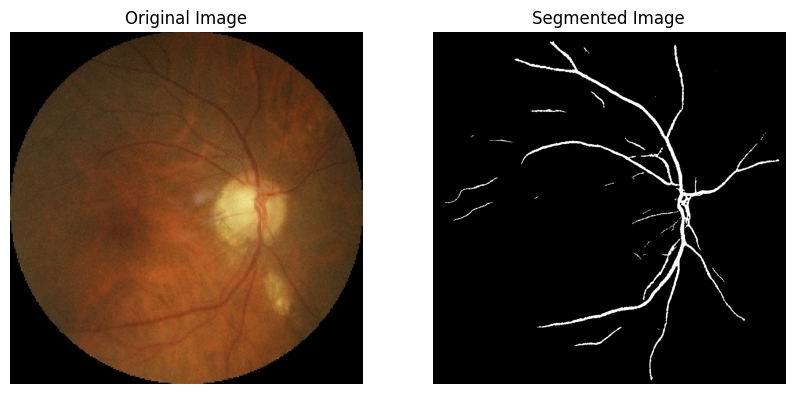

In [ ]:
import matplotlib.pyplot as plt
from skimage import io

# Example segmented images from the output directory
original_img_path = "/content/drive/MyDrive/Automorph/testing/RG/EyePACS-Glaucoma-2794.jpg"
segmented_img_path = "/content/drive/MyDrive/Automorph/result_images/segmented_EyePACS-Glaucoma-2794.jpg.png"

def display_comparisons(original_img_path, segmented_img_path):
    original_img = io.imread(original_img_path)
    segmented_img = io.imread(segmented_img_path)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(original_img, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Segmented Image")
    plt.imshow(segmented_img, cmap='gray')
    plt.axis("off")

    plt.show()

# Display
display_comparisons(original_img_path, segmented_img_path)


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
features_df = pd.read_csv("/content/drive/MyDrive/Automorph/glaucoma_features.csv")

def plot_feature_distributions(features_df):
    plt.figure(figsize=(15, 5))

    # Fractal Dimension
    plt.subplot(1, 3, 1)
    sns.histplot(data=features_df, x='FD_cal', hue='glaucoma_label', kde=True, bins=20, palette='cool')
    plt.title("Fractal Dimension Distribution")
    plt.xlabel("Fractal Dimension")
    plt.ylabel("Frequency")

    # Vessel Density
    plt.subplot(1, 3, 2)
    sns.histplot(data=features_df, x='VD_cal', hue='glaucoma_label', kde=True, bins=20, palette='cool')
    plt.title("Vessel Density Distribution")
    plt.xlabel("Vessel Density")
    plt.ylabel("Frequency")

    # Vessel Width
    plt.subplot(1, 3, 3)
    sns.histplot(data=features_df, x='width_cal', hue='glaucoma_label', kde=True, bins=20, palette='cool')
    plt.title("Vessel Width Distribution")
    plt.xlabel("Vessel Width")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Plot distributions
plot_feature_distributions(features_df)


In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
import pandas as pd

# Path to your CSV file
csv_file_path = "/content/drive/MyDrive/Automorph/glaucoma_features_validation_data.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(csv_file_path)

# Check the first few rows to ensure the data loaded correctly
print(df.head())


     FD_cal    VD_cal  width_cal  glaucoma_label                 image_name
0  1.386136  0.051913   5.598807               1  EyePACS-Glaucoma-2513.jpg
1  1.428348  0.060509   5.266088               1  EyePACS-Glaucoma-2510.jpg
2  1.380490  0.050258   5.990542               1  EyePACS-Glaucoma-2507.jpg
3  1.398312  0.056562   6.039153               1  EyePACS-Glaucoma-2508.jpg
4  1.392748  0.051257   6.133362               1  EyePACS-Glaucoma-2509.jpg


In [ ]:
# Define thresholds for classification
fd_threshold = 1.6
vd_threshold = 0.4

# Apply rule-based classification
df['predicted_label'] = df.apply(lambda row: 1 if (row['FD_cal'] < fd_threshold and row['VD_cal'] < vd_threshold) else 0, axis=1)


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

# Extract the ground truth and predictions
y_true = df['glaucoma_label']  # Ground truth labels
y_pred = df['predicted_label']  # Predicted labels

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred)  # Sensitivity = Recall
specificity = tn / (tn + fp)

# Print results
print(f"Confusion Matrix: \nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Sensitivity (Recall): {sensitivity:.2f}")
print(f"Specificity: {specificity:.2f}")


NameError: name 'df' is not defined